# This notebook reproduces following figures: Fig. 1, Fig. S1, Fig. S2.

Following network files were used to simulate the networks:
- nw_iall_stability.py
- nw_ie_stability.py
- nw_ii_stability.py

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import TwoSlopeNorm
import copy

## Fig 1: Co-active inhibitory plasticity drives long-term stable network activity.

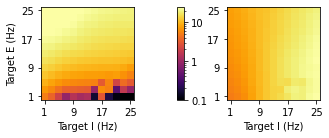

In [2]:
csv_path = "data/fig1/iall_param_sweep_summary.csv"
VALUE_COL_EXC = "rate_exc_hz"
VALUE_COL_INH = "rate_inh_hz"

VMIN, VMAX = 0.1, 25
FIGSIZE = (5, 2)

TARGET_E_MAX = 25
TARGET_I_MAX = 25

CBAR_TICKS = [0.1, 1, 10, 50]

df = pd.read_csv(csv_path)
df = df.dropna(subset=["target_e", "target_i", VALUE_COL_EXC, VALUE_COL_INH])

df = df[(df["target_e"] <= TARGET_E_MAX) & (df["target_i"] <= TARGET_I_MAX)]

target_es = np.sort(df["target_e"].unique())
target_is = np.sort(df["target_i"].unique())

e_index = {v: i for i, v in enumerate(target_es)}
i_index = {v: i for i, v in enumerate(target_is)}

heat_exc = np.full((len(target_es), len(target_is)), np.nan)
heat_inh = np.full((len(target_es), len(target_is)), np.nan)

for _, r in df.iterrows():
    i = e_index[r["target_e"]]
    j = i_index[r["target_i"]]
    heat_exc[i, j] = float(r[VALUE_COL_EXC])
    heat_inh[i, j] = float(r[VALUE_COL_INH])

heat_exc = np.ma.masked_where(heat_exc <= 0, heat_exc)
heat_inh = np.ma.masked_where(heat_inh <= 0, heat_inh)

norm = LogNorm(vmin=VMIN, vmax=VMAX)

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)

imL = axL.imshow(
    heat_exc,
    origin="lower",
    cmap="inferno",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

imR = axR.imshow(
    heat_inh,
    origin="lower",
    cmap="inferno",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

axL.set_box_aspect(1)
axR.set_box_aspect(1)

fig.subplots_adjust(wspace=1)

step_e = max(1, len(target_es) // 3)
step_i = max(1, len(target_is) // 3)

yticks = list(range(0, len(target_es), step_e))
ylabels = [int(x) for x in target_es[::step_e]]
xticks = list(range(0, len(target_is), step_i))
xlabels = [int(x) for x in target_is[::step_i]]

for ax in (axL, axR):
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Target I (Hz)")

axL.set_ylabel("Target E (Hz)")
axR.set_ylabel("")

fig.canvas.draw()

posL = axL.get_position()
posR = axR.get_position()

gap_left = posL.x1
gap_right = posR.x0
gap = gap_right - gap_left

cbar_width = min(0.02, gap * 0.6)
cbar_x = gap_left + (gap - cbar_width) / 2
cbar_y = posL.y0
cbar_h = posL.height

cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_h])

cbar = fig.colorbar(imL, cax=cax)
cbar.set_ticks(CBAR_TICKS)
cbar.set_ticklabels([str(t) for t in CBAR_TICKS])

plt.show()

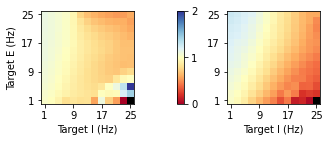

In [3]:
csv_path = "data/fig1/iall_param_sweep_summary.csv"
VALUE_COL_EXC = "cv_isi_exc"
VALUE_COL_INH = "cv_isi_inh"

FIGSIZE = (5, 2)
CMAP = "RdYlBu"

VCENTER = 1.0
CV_MIN = 0.7
CV_MAX = 1.5
DRAW_CONTOUR = False

TICK_DIV = 3
NAN_COLOR = "black"

TARGET_E_MAX = 25
TARGET_I_MAX = 25

df = pd.read_csv(csv_path)

required = ["target_e", "target_i", VALUE_COL_EXC, VALUE_COL_INH]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}\nAvailable columns: {df.columns.tolist()}"
    )

df = df.dropna(subset=required)
df = df[df["target_e"] <= TARGET_E_MAX]
df = df[df["target_i"] <= TARGET_I_MAX]

dfg = (
    df.groupby(["target_e", "target_i"], as_index=False)
      .agg({VALUE_COL_EXC: "mean", VALUE_COL_INH: "mean"})
)

target_es = np.sort(dfg["target_e"].unique())
target_is = np.sort(dfg["target_i"].unique())

e_index = {v: i for i, v in enumerate(target_es)}
i_index = {v: i for i, v in enumerate(target_is)}

heat_exc = np.full((len(target_es), len(target_is)), np.nan)
heat_inh = np.full((len(target_es), len(target_is)), np.nan)

for _, r in dfg.iterrows():
    heat_exc[e_index[r["target_e"]], i_index[r["target_i"]]] = r[VALUE_COL_EXC]
    heat_inh[e_index[r["target_e"]], i_index[r["target_i"]]] = r[VALUE_COL_INH]

finite_vals = np.concatenate([
    heat_exc[np.isfinite(heat_exc)].ravel(),
    heat_inh[np.isfinite(heat_inh)].ravel(),
])

if finite_vals.size == 0:
    raise ValueError("No finite CV values to plot.")

vmin = 0
vmax = 2
eps = 1e-6
if not (vmin < VCENTER < vmax):
    vmin = min(vmin, VCENTER - eps)
    vmax = max(vmax, VCENTER + eps)

norm = TwoSlopeNorm(vmin=vmin, vcenter=VCENTER, vmax=vmax)

cmap = copy.copy(plt.get_cmap(CMAP))
cmap.set_bad(color=NAN_COLOR)

heat_exc = np.ma.masked_invalid(heat_exc)
heat_inh = np.ma.masked_invalid(heat_inh)

def band_for_contour(hm):
    mask = np.zeros_like(hm, dtype=bool)
    finite = np.isfinite(hm)
    mask[finite] = (hm[finite] >= CV_MIN) & (hm[finite] <= CV_MAX)
    return np.ma.masked_where(~finite, mask.astype(float))

band_exc = band_for_contour(heat_exc)
band_inh = band_for_contour(heat_inh)

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)
fig.subplots_adjust(wspace=1)

imL = axL.imshow(
    heat_exc,
    origin="lower",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)
imR = axR.imshow(
    heat_inh,
    origin="lower",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

axL.set_box_aspect(1)
axR.set_box_aspect(1)

if DRAW_CONTOUR:
    axL.contour(band_exc, levels=[0.5], colors="red", linewidths=2.5, origin="lower")
    axR.contour(band_inh, levels=[0.5], colors="red", linewidths=2.5, origin="lower")

step_e = max(1, len(target_es) // TICK_DIV)
step_i = max(1, len(target_is) // TICK_DIV)

yticks = range(0, len(target_es), step_e)
xticks = range(0, len(target_is), step_i)

for ax in (axL, axR):
    ax.set_yticks(yticks)
    ax.set_yticklabels([int(x) for x in target_es[::step_e]])
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in target_is[::step_i]])
    ax.set_xlabel("Target I (Hz)")

axL.set_ylabel("Target E (Hz)")
axR.set_ylabel("")

fig.canvas.draw()

posL = axL.get_position()
posR = axR.get_position()

gap = posR.x0 - posL.x1
cbar_width = min(0.02, gap * 0.6)

cax = fig.add_axes([
    posL.x1 + (gap - cbar_width) / 2,
    posL.y0,
    cbar_width,
    posL.height,
])

cbar = fig.colorbar(imL, cax=cax)
cbar.set_ticks([vmin, VCENTER, vmax])

plt.show()

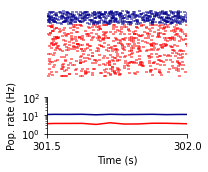

In [4]:
data = np.loadtxt("data/fig1/spikes_4000s.txt")
neuron = data[:, 0].astype(int)
time   = data[:, 1]

tmin, tmax = 301.5, 302.0
bin_width  = 0.05

E_MIN, E_MAX = 0, 8000
I_MIN, I_MAX = 8000, 10000
N_E, N_I = 8000, 2000

rng = np.random.default_rng(0)

exc_ids_show = rng.choice(np.arange(E_MIN, E_MAX), size=400, replace=False)
inh_ids_show = rng.choice(np.arange(I_MIN, I_MAX), size=100, replace=False)

mask_exc_show = np.isin(neuron, exc_ids_show)
mask_inh_show = np.isin(neuron, inh_ids_show)

grp_exc = (neuron >= E_MIN) & (neuron < E_MAX)
grp_inh = (neuron >= I_MIN) & (neuron < I_MAX)

bins = np.arange(time.min(), time.max() + bin_width, bin_width)

counts_exc, _ = np.histogram(time[grp_exc], bins=bins)
counts_inh, _ = np.histogram(time[grp_inh], bins=bins)

rate_exc = counts_exc / (N_E * bin_width)
rate_inh = counts_inh / (N_I * bin_width)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, (ax_raster, ax_rate) = plt.subplots(
    2, 1, figsize=(3, 2.5),
    gridspec_kw={'height_ratios': [2, 1]},
    sharex=True
)

exc_times = [
    time[(neuron == nid) & (time >= tmin) & (time <= tmax)]
    for nid in exc_ids_show
]

ax_raster.eventplot(
    exc_times,
    colors='red',
    lineoffsets=exc_ids_show,
    linelengths=150,
    linewidths=3
)

inh_times = [
    time[(neuron == nid) & (time >= tmin) & (time <= tmax)]
    for nid in inh_ids_show
]

ax_raster.eventplot(
    inh_times,
    colors='darkblue',
    lineoffsets=inh_ids_show,
    linelengths=150,
    linewidths=3
)

ax_raster.set_ylabel("Neurons")

ax_rate.plot(bin_centers, rate_exc, c='red', label="Exc")
ax_rate.plot(bin_centers, rate_inh, c='darkblue', label="Inh")
ax_rate.set_ylabel("Pop. rate (Hz)")
ax_rate.set_xlabel("Time (s)")

ax_raster.set_xlim(tmin, tmax)
ax_rate.set_xlim(tmin, tmax)
ax_rate.set_ylim(1, 100)
ax_rate.set_yscale("log")

ax_rate.spines["top"].set_visible(False)
ax_rate.spines["right"].set_visible(False)

ax_rate.set_xticks([tmin, tmax])
ax_rate.set_xticklabels([f"{tmin:.1f}", f"{tmax:.1f}"])

ax_raster.set_axis_off()

plt.tight_layout()
plt.show()


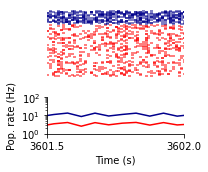

In [5]:
data = np.loadtxt("data/fig1/spikes_4000s.txt")
neuron = data[:, 0].astype(int)
time   = data[:, 1]

tmin, tmax = 3601.5, 3602.0
bin_width  = 0.05

E_MIN, E_MAX = 0, 8000
I_MIN, I_MAX = 8000, 10000
N_E, N_I = 8000, 2000

rng = np.random.default_rng(0)

exc_ids_show = rng.choice(np.arange(E_MIN, E_MAX), size=400, replace=False)
inh_ids_show = rng.choice(np.arange(I_MIN, I_MAX), size=100, replace=False)

mask_exc_show = np.isin(neuron, exc_ids_show)
mask_inh_show = np.isin(neuron, inh_ids_show)

grp_exc = (neuron >= E_MIN) & (neuron < E_MAX)
grp_inh = (neuron >= I_MIN) & (neuron < I_MAX)

bins = np.arange(time.min(), time.max() + bin_width, bin_width)

counts_exc, _ = np.histogram(time[grp_exc], bins=bins)
counts_inh, _ = np.histogram(time[grp_inh], bins=bins)

rate_exc = counts_exc / (N_E * bin_width)
rate_inh = counts_inh / (N_I * bin_width)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, (ax_raster, ax_rate) = plt.subplots(
    2, 1, figsize=(3, 2.5),
    gridspec_kw={'height_ratios': [2, 1]},
    sharex=True
)

exc_times = [
    time[(neuron == nid) & (time >= tmin) & (time <= tmax)]
    for nid in exc_ids_show
]

ax_raster.eventplot(
    exc_times,
    colors='red',
    lineoffsets=exc_ids_show,
    linelengths=150,
    linewidths=3
)

inh_times = [
    time[(neuron == nid) & (time >= tmin) & (time <= tmax)]
    for nid in inh_ids_show
]

ax_raster.eventplot(
    inh_times,
    colors='darkblue',
    lineoffsets=inh_ids_show,
    linelengths=150,
    linewidths=3
)

ax_raster.set_ylabel("Neurons")

ax_rate.plot(bin_centers, rate_exc, c='red', label="Exc")
ax_rate.plot(bin_centers, rate_inh, c='darkblue', label="Inh")
ax_rate.set_ylabel("Pop. rate (Hz)")
ax_rate.set_xlabel("Time (s)")

ax_raster.set_xlim(tmin, tmax)
ax_rate.set_xlim(tmin, tmax)
ax_rate.set_ylim(1, 100)
ax_rate.set_yscale("log")

ax_rate.spines["top"].set_visible(False)
ax_rate.spines["right"].set_visible(False)

ax_rate.set_xticks([tmin, tmax])
ax_rate.set_xticklabels([f"{tmin:.1f}", f"{tmax:.1f}"])

ax_raster.set_axis_off()

plt.tight_layout()
plt.show()


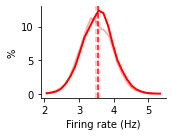

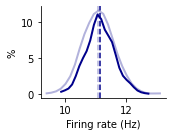

In [6]:
data = np.loadtxt("data/fig1/spikes_4000s.txt")
neuron = data[:, 0].astype(int)
time   = data[:, 1]

E_MIN, E_MAX = 0, 8000
I_MIN, I_MAX = 8000, 10000
N_E, N_I = 8000, 2000

windows = [(300.0, 310.0), (3600.0, 3610.0)]
alphas  = [1.0, 0.3] 

bins_e = 25
bins_i = 25
sigma_bins = 1.2

def gaussian_kernel1d(sigma_bins, radius=4):
    r = int(np.ceil(radius * sigma_bins))
    x = np.arange(-r, r + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    k /= k.sum()
    return k

def smooth_curve(y, sigma_bins=1.2):
    k = gaussian_kernel1d(sigma_bins)
    return np.convolve(y, k, mode="same")

def smooth_percent_hist(ax, x, bins, N, color, alpha=1.0, label=None, sigma_bins=1.2):
    counts, edges = np.histogram(x, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])

    y = counts * 100.0 / N
    y_s = smooth_curve(y, sigma_bins=sigma_bins)

    ax.plot(centers, y_s, color=color, lw=2, alpha=alpha, label=label)

    mu = x.mean()
    ax.axvline(mu, color=color, ls="--", lw=1.5, alpha=alpha)

    ax.set_ylabel("%")
    ax.set_xlabel("Firing rate (Hz)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return mu

def rates_in_window(tmin, tmax):
    T = tmax - tmin
    mask = (time >= tmin) & (time <= tmax)
    neuron_w = neuron[mask]

    exc_counts = np.bincount(
        neuron_w[(neuron_w >= E_MIN) & (neuron_w < E_MAX)] - E_MIN,
        minlength=N_E
    )
    inh_counts = np.bincount(
        neuron_w[(neuron_w >= I_MIN) & (neuron_w < I_MAX)] - I_MIN,
        minlength=N_I
    )

    exc_rates = exc_counts / T
    inh_rates = inh_counts / T
    return exc_rates, inh_rates

fig, ax = plt.subplots(figsize=(2.5, 2))
for (tmin, tmax), a in zip(windows, alphas):
    exc_rates, _ = rates_in_window(tmin, tmax)
    smooth_percent_hist(
        ax, exc_rates, bins=bins_e, N=N_E,
        color="red", alpha=a,
        label=f"{int(tmin)}-{int(tmax)} s",
        sigma_bins=sigma_bins
    )
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(2.5, 2))
for (tmin, tmax), a in zip(windows, alphas):
    _, inh_rates = rates_in_window(tmin, tmax)
    smooth_percent_hist(
        ax, inh_rates, bins=bins_i, N=N_I,
        color="darkblue", alpha=a,
        label=f"{int(tmin)}-{int(tmax)} s",
        sigma_bins=sigma_bins
    )
plt.tight_layout()
plt.show()


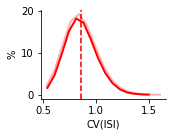

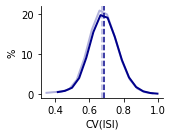

In [7]:
data = np.loadtxt("data/fig1/spikes_4000s.txt")
neuron = data[:, 0].astype(int)
time   = data[:, 1]

E_MIN, E_MAX = 0, 8000
I_MIN, I_MAX = 8000, 10000
N_E, N_I = 8000, 2000

windows = [(300.0, 310.0), (3600.0, 3610.0)]
alphas  = [1.0, 0.3]

def cv_isi_distribution(neuron_w, time_w, pop_min, pop_max):
    N = pop_max - pop_min
    spikes = [[] for _ in range(N)]
    in_pop = (neuron_w >= pop_min) & (neuron_w < pop_max)

    for nid, t in zip(neuron_w[in_pop] - pop_min, time_w[in_pop]):
        spikes[nid].append(t)

    cv_vals = []
    n0 = n1 = n2 = 0

    for ts in spikes:
        k = len(ts)
        if k == 0:
            n0 += 1; continue
        if k == 1:
            n1 += 1; continue
        if k == 2:
            n2 += 1; continue

        ts = np.sort(ts)
        isi = np.diff(ts)
        m = isi.mean()
        if m > 0:
            cv_vals.append(isi.std(ddof=0) / m)

    cv_vals = np.asarray(cv_vals)
    return cv_vals, n0, n1, n2, cv_vals.size

def gaussian_kernel1d(sigma_bins, radius=4):
    r = int(np.ceil(radius * sigma_bins))
    x = np.arange(-r, r + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    k /= k.sum()
    return k

def smooth_curve(y, sigma_bins=1.2):
    k = gaussian_kernel1d(sigma_bins)
    return np.convolve(y, k, mode="same")

def smooth_percent_hist(ax, x, bins, N_total, color, alpha=1.0, label=None, sigma_bins=1.2):
    counts, edges = np.histogram(x, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])

    y = counts * 100.0 / N_total
    y_s = smooth_curve(y, sigma_bins=sigma_bins)

    ax.plot(centers, y_s, color=color, lw=2, alpha=alpha, label=label)

    mu = x.mean() if x.size else np.nan
    ax.axvline(mu, color=color, ls="--", lw=1.5, alpha=alpha)

    ax.set_ylabel("%")
    ax.set_xlabel("CV(ISI)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return mu

def windowed_arrays(tmin, tmax):
    mask = (time >= tmin) & (time <= tmax)
    return neuron[mask], time[mask]

bins_cv = 15
sigma_bins = 1.2

fig, ax = plt.subplots(figsize=(2.5, 2))
for (tmin, tmax), a in zip(windows, alphas):
    neuron_w, time_w = windowed_arrays(tmin, tmax)
    cv_exc, *_ = cv_isi_distribution(neuron_w, time_w, E_MIN, E_MAX)
    smooth_percent_hist(
        ax, cv_exc, bins=bins_cv, N_total=N_E,
        color="red", alpha=a,
        label=f"{int(tmin)}-{int(tmax)} s",
        sigma_bins=sigma_bins
    )
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(2.5, 2))
for (tmin, tmax), a in zip(windows, alphas):
    neuron_w, time_w = windowed_arrays(tmin, tmax)
    cv_inh, *_ = cv_isi_distribution(neuron_w, time_w, I_MIN, I_MAX)
    smooth_percent_hist(
        ax, cv_inh, bins=bins_cv, N_total=N_I,
        color="darkblue", alpha=a,
        label=f"{int(tmin)}-{int(tmax)} s",
        sigma_bins=sigma_bins
    )
plt.tight_layout()
plt.show()


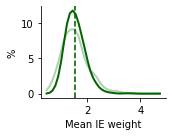

In [8]:
w_IE = np.loadtxt("data/fig1/weights_IE_4000s.txt")
time_IE = w_IE[:, 0]
weights_IE = w_IE[:, 1:]

N_IE = weights_IE.shape[1]

windows = [(300.0, 310.0), (3600.0, 3610.0)]
alphas  = [1.0, 0.3]

def gaussian_kernel1d(sigma_bins, radius=4):
    r = int(np.ceil(radius * sigma_bins))
    x = np.arange(-r, r + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    k /= k.sum()
    return k

def smooth_curve(y, sigma_bins=1.2):
    return np.convolve(y, gaussian_kernel1d(sigma_bins), mode="same")

def smooth_percent_hist(ax, x, bins, N_total, color, alpha=1.0, label=None, sigma_bins=1.2):
    counts, edges = np.histogram(x, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])

    y = counts * 100.0 / N_total
    y_s = smooth_curve(y, sigma_bins=sigma_bins)

    ax.plot(centers, y_s, color=color, lw=2, alpha=alpha, label=label)

    mu = x.mean() if x.size else np.nan
    ax.axvline(mu, color=color, ls="--", lw=1.5, alpha=alpha)

    ax.set_ylabel("%")
    ax.set_xlabel("Mean IE weight")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return mu

def mean_weights_in_window(tmin, tmax):
    m = (time_IE >= tmin) & (time_IE <= tmax)
    if not np.any(m):
        return np.array([])
    return weights_IE[m].mean(axis=0)

means = [mean_weights_in_window(tmin, tmax) for (tmin, tmax) in windows]
all_vals = np.concatenate([x for x in means if x.size]) if any(x.size for x in means) else np.array([0.0, 1.0])

bins = np.histogram_bin_edges(all_vals, bins=40)

fig, ax = plt.subplots(figsize=(2.5, 2))
for (tmin, tmax), a, x in zip(windows, alphas, means):
    smooth_percent_hist(
        ax, x, bins=bins, N_total=N_IE,
        color="darkgreen", alpha=a,
        label=f"{int(tmin)}-{int(tmax)} s",
        sigma_bins=1.2
    )

plt.tight_layout()
plt.show()


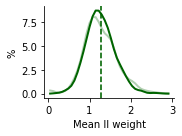

In [9]:
w_II = np.loadtxt("data/fig1/weights_II_4000s.txt")
time_II = w_II[:, 0]
weights_II = w_II[:, 1:]

N_II = weights_II.shape[1]

windows = [(300.0, 310.0), (3600.0, 3610.0)]
alphas  = [1.0, 0.3]

def gaussian_kernel1d(sigma_bins, radius=4):
    r = int(np.ceil(radius * sigma_bins))
    x = np.arange(-r, r + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    k /= k.sum()
    return k

def smooth_curve(y, sigma_bins=1.2):
    return np.convolve(y, gaussian_kernel1d(sigma_bins), mode="same")

def smooth_percent_hist(ax, x, bins, N_total, color, alpha=1.0, label=None, sigma_bins=1.2):
    counts, edges = np.histogram(x, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])

    y = counts * 100.0 / N_total
    y_s = smooth_curve(y, sigma_bins=sigma_bins)

    ax.plot(centers, y_s, color=color, lw=2, alpha=alpha, label=label)

    mu = x.mean() if x.size else np.nan
    ax.axvline(mu, color=color, ls="--", lw=1.5, alpha=alpha)

    ax.set_ylabel("%")
    ax.set_xlabel("Mean II weight")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return mu

def mean_weights_in_window(tmin, tmax):
    m = (time_II >= tmin) & (time_II <= tmax)
    if not np.any(m):
        return np.array([])
    return weights_II[m].mean(axis=0)

means = [mean_weights_in_window(tmin, tmax) for (tmin, tmax) in windows]

all_vals = np.concatenate([x for x in means if x.size]) if any(x.size for x in means) else np.array([0.0, 1.0])
bins = np.histogram_bin_edges(all_vals, bins=40)

fig, ax = plt.subplots(figsize=(2.5, 2))
for (tmin, tmax), a, x in zip(windows, alphas, means):
    smooth_percent_hist(
        ax, x, bins=bins, N_total=N_II,
        color="darkgreen", alpha=a,
        label=f"{int(tmin)}-{int(tmax)} s",
        sigma_bins=1.2
    )

plt.tight_layout()
plt.show()


## Fig S1: Parameter search over target firing rates of the co-active ISP.

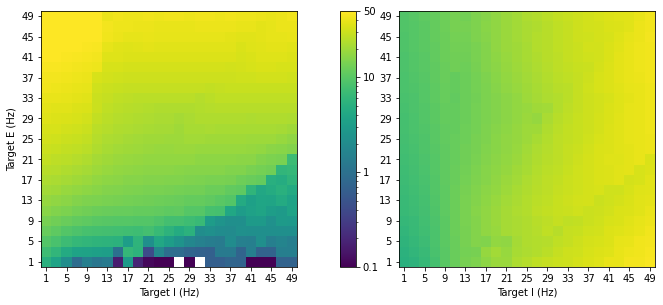

In [10]:
csv_path = "data/fig1/iall_param_sweep_summary.csv"
VALUE_COL_EXC = "rate_exc_hz"
VALUE_COL_INH = "rate_inh_hz"

VMIN, VMAX = 0.1, 50
FIGSIZE = (11, 5)

TARGET_E_MAX = 50
TARGET_I_MAX = 50

CBAR_TICKS = [0.1, 1, 10, 50]

df = pd.read_csv(csv_path)
df = df.dropna(subset=["target_e", "target_i", VALUE_COL_EXC, VALUE_COL_INH])

df = df[(df["target_e"] <= TARGET_E_MAX) & (df["target_i"] <= TARGET_I_MAX)]

target_es = np.sort(df["target_e"].unique())
target_is = np.sort(df["target_i"].unique())

e_index = {v: i for i, v in enumerate(target_es)}
i_index = {v: i for i, v in enumerate(target_is)}

heat_exc = np.full((len(target_es), len(target_is)), np.nan)
heat_inh = np.full((len(target_es), len(target_is)), np.nan)

for _, r in df.iterrows():
    i = e_index[r["target_e"]]
    j = i_index[r["target_i"]]
    heat_exc[i, j] = float(r[VALUE_COL_EXC])
    heat_inh[i, j] = float(r[VALUE_COL_INH])

heat_exc = np.ma.masked_where(heat_exc <= 0, heat_exc)
heat_inh = np.ma.masked_where(heat_inh <= 0, heat_inh)

norm = LogNorm(vmin=VMIN, vmax=VMAX)

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)

imL = axL.imshow(
    heat_exc,
    origin="lower",
    cmap="viridis",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

imR = axR.imshow(
    heat_inh,
    origin="lower",
    cmap="viridis",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

axL.set_box_aspect(1)
axR.set_box_aspect(1)

fig.subplots_adjust(wspace=0.4)

step_e = max(1, len(target_es) // 10)
step_i = max(1, len(target_is) // 10)

yticks = list(range(0, len(target_es), step_e))
ylabels = [int(x) for x in target_es[::step_e]]
xticks = list(range(0, len(target_is), step_i))
xlabels = [int(x) for x in target_is[::step_i]]

for ax in (axL, axR):
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Target I (Hz)")

axL.set_ylabel("Target E (Hz)")
axR.set_ylabel("")

fig.canvas.draw()

posL = axL.get_position()
posR = axR.get_position()

gap_left = posL.x1
gap_right = posR.x0
gap = gap_right - gap_left

cbar_width = min(0.02, gap * 0.6)
cbar_x = gap_left + (gap - cbar_width) / 2
cbar_y = posL.y0
cbar_h = posL.height

cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_h])

cbar = fig.colorbar(imL, cax=cax)
cbar.set_ticks(CBAR_TICKS)
cbar.set_ticklabels([str(t) for t in CBAR_TICKS])

plt.show()


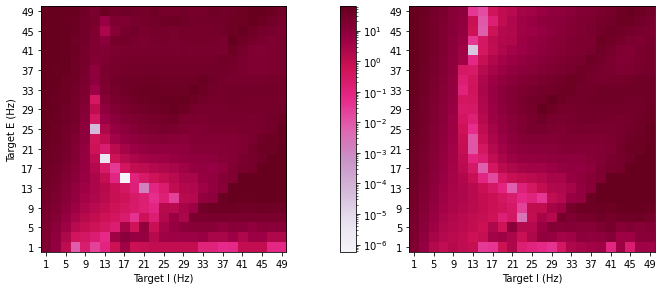

In [11]:
csv_path = "data/fig1/iall_param_sweep_summary.csv"
FIGSIZE = (11, 5)

TARGET_I_MAX = 50

df = pd.read_csv(csv_path)

required = ["target_e", "target_i", "rate_exc_hz", "rate_inh_hz"]
df = df.dropna(subset=required)

df = df[df["target_i"] <= TARGET_I_MAX]

df["mse_exc"] = (df["rate_exc_hz"] - df["target_e"]) ** 2
df["mse_inh"] = (df["rate_inh_hz"] - df["target_i"]) ** 2

dfg = (
    df.groupby(["target_e", "target_i"], as_index=False)
      .agg({"mse_exc": "mean", "mse_inh": "mean"})
)

target_es = np.sort(dfg["target_e"].unique())
target_is = np.sort(dfg["target_i"].unique())  # will now end at <= 49

e_index = {v: i for i, v in enumerate(target_es)}
i_index = {v: i for i, v in enumerate(target_is)}

heat_exc = np.full((len(target_es), len(target_is)), np.nan, dtype=float)
heat_inh = np.full((len(target_es), len(target_is)), np.nan, dtype=float)

for _, r in dfg.iterrows():
    i = e_index[r["target_e"]]
    j = i_index[r["target_i"]]
    heat_exc[i, j] = float(r["mse_exc"])
    heat_inh[i, j] = float(r["mse_inh"])

finite = np.concatenate([
    heat_exc[np.isfinite(heat_exc)].ravel(),
    heat_inh[np.isfinite(heat_inh)].ravel()
])

if finite.size == 0:
    raise ValueError("No finite MSE values to plot.")

positive = finite[finite > 0]
if positive.size == 0:
    raise ValueError("No positive MSE values to plot with LogNorm.")

vmin = np.min(positive)
vmax = np.percentile(positive, 95)

norm = LogNorm(vmin=vmin, vmax=vmax)

heat_exc = np.ma.masked_where(heat_exc <= 0, heat_exc)
heat_inh = np.ma.masked_where(heat_inh <= 0, heat_inh)

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)
fig.subplots_adjust(wspace=0.5)

imL = axL.imshow(
    heat_exc,
    origin="lower",
    cmap="PuRd",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)
imR = axR.imshow(
    heat_inh,
    origin="lower",
    cmap="PuRd",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

axL.set_box_aspect(1)
axR.set_box_aspect(1)

step_e = max(1, len(target_es) // 10)
step_i = max(1, len(target_is) // 10)

yticks = list(range(0, len(target_es), step_e))
xticks = list(range(0, len(target_is), step_i))
ylabels = [int(x) for x in target_es[::step_e]]
xlabels = [int(x) for x in target_is[::step_i]]

for ax in (axL, axR):
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Target I (Hz)")

axL.set_ylabel("Target E (Hz)")
axR.set_ylabel("")

fig.canvas.draw()

posL = axL.get_position()
posR = axR.get_position()

gap_left = posL.x1
gap_right = posR.x0
gap = gap_right - gap_left

cbar_width = min(0.02, gap * 0.6)
cbar_x = gap_left + (gap - cbar_width) / 2
cbar_y = posL.y0
cbar_h = posL.height

cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_h])

cbar = fig.colorbar(imL, cax=cax)

plt.show()


/home/mkania/miniforge3/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:36: RuntimeWarning: invalid value encountered in less_equal
/home/mkania/miniforge3/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:37: RuntimeWarning: invalid value encountered in less_equal
/home/mkania/miniforge3/envs/py36/lib/python3.6/site-packages/matplotlib/colors.py:1207: RuntimeWarning: invalid value encountered in less_equal
  mask |= resdat <= 0


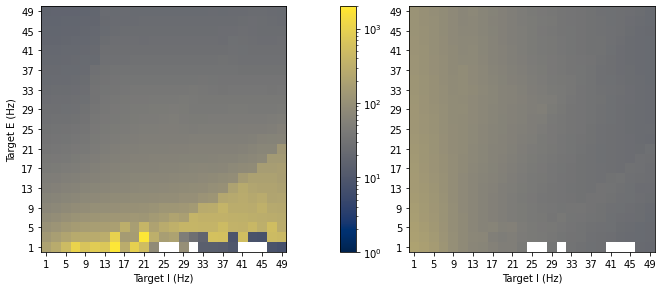

In [12]:
csv_path = "data/fig1/iall_param_sweep_summary.csv"
VALUE_COL_EXC = "mean_isi_exc"
VALUE_COL_INH = "mean_isi_inh"

FIGSIZE = (11, 5)

TARGET_I_MAX = 50
MS_SCALE = 1000.0

vmin = 1
vmax = 2000
norm = LogNorm(vmin=vmin, vmax=vmax)

df = pd.read_csv(csv_path)

required = ["target_e", "target_i", VALUE_COL_EXC, VALUE_COL_INH]
df = df.dropna(subset=required)

df = df[df["target_i"] <= TARGET_I_MAX]

target_es = np.sort(df["target_e"].unique())
target_is = np.sort(df["target_i"].unique())

e_index = {v: i for i, v in enumerate(target_es)}
i_index = {v: i for i, v in enumerate(target_is)}

heat_exc = np.full((len(target_es), len(target_is)), np.nan, dtype=float)
heat_inh = np.full((len(target_es), len(target_is)), np.nan, dtype=float)

for _, r in df.iterrows():
    i = e_index[r["target_e"]]
    j = i_index[r["target_i"]]
    heat_exc[i, j] = float(r[VALUE_COL_EXC]) * MS_SCALE
    heat_inh[i, j] = float(r[VALUE_COL_INH]) * MS_SCALE

heat_exc = np.ma.masked_where(~np.isfinite(heat_exc) | (heat_exc <= 0), heat_exc)
heat_inh = np.ma.masked_where(~np.isfinite(heat_inh) | (heat_inh <= 0), heat_inh)

finite_vals = np.concatenate([
    heat_exc.compressed() if hasattr(heat_exc, "compressed") else heat_exc[np.isfinite(heat_exc)],
    heat_inh.compressed() if hasattr(heat_inh, "compressed") else heat_inh[np.isfinite(heat_inh)],
])
if finite_vals.size == 0:
    raise ValueError("No finite ISI values to plot.")

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)
fig.subplots_adjust(wspace=0.5)

imL = axL.imshow(
    heat_exc,
    origin="lower",
    cmap="cividis",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)
imR = axR.imshow(
    heat_inh,
    origin="lower",
    cmap="cividis",
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

axL.set_box_aspect(1)
axR.set_box_aspect(1)

step_e = max(1, len(target_es) // 10)
step_i = max(1, len(target_is) // 10)

yticks = list(range(0, len(target_es), step_e))
xticks = list(range(0, len(target_is), step_i))
ylabels = [int(x) for x in target_es[::step_e]]
xlabels = [int(x) for x in target_is[::step_i]]

for ax in (axL, axR):
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Target I (Hz)")

axL.set_ylabel("Target E (Hz)")
axR.set_ylabel("")

fig.canvas.draw()
posL = axL.get_position()
posR = axR.get_position()
gap = posR.x0 - posL.x1

cbar_width = min(0.02, gap * 0.6)
cbar_x = posL.x1 + (gap - cbar_width) / 2
cbar_y = posL.y0
cbar_h = posL.height

cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_h])
cbar = fig.colorbar(imL, cax=cax)

plt.show()


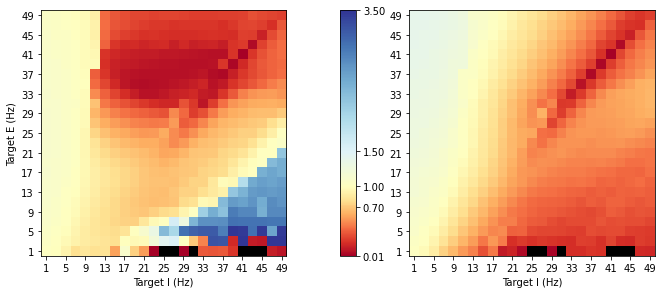

In [13]:
csv_path = "data/fig1/iall_param_sweep_summary.csv"
VALUE_COL_EXC = "cv_isi_exc"
VALUE_COL_INH = "cv_isi_inh"

FIGSIZE = (11, 5)
CMAP = "RdYlBu"

VCENTER = 1.0
CV_MIN = 0.7
CV_MAX = 1.5
DRAW_CONTOUR = False

TICK_DIV = 10
NAN_COLOR = "black"

TARGET_I_MAX = 50

df = pd.read_csv(csv_path)

required = ["target_e", "target_i", VALUE_COL_EXC, VALUE_COL_INH]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}\nAvailable columns: {df.columns.tolist()}"
    )

df = df.dropna(subset=required)
df = df[df["target_i"] <= TARGET_I_MAX]

dfg = (
    df.groupby(["target_e", "target_i"], as_index=False)
      .agg({VALUE_COL_EXC: "mean", VALUE_COL_INH: "mean"})
)

target_es = np.sort(dfg["target_e"].unique())
target_is = np.sort(dfg["target_i"].unique())

e_index = {v: i for i, v in enumerate(target_es)}
i_index = {v: i for i, v in enumerate(target_is)}

heat_exc = np.full((len(target_es), len(target_is)), np.nan)
heat_inh = np.full((len(target_es), len(target_is)), np.nan)

for _, r in dfg.iterrows():
    heat_exc[e_index[r["target_e"]], i_index[r["target_i"]]] = r[VALUE_COL_EXC]
    heat_inh[e_index[r["target_e"]], i_index[r["target_i"]]] = r[VALUE_COL_INH]

finite_vals = np.concatenate([
    heat_exc[np.isfinite(heat_exc)].ravel(),
    heat_inh[np.isfinite(heat_inh)].ravel(),
])

if finite_vals.size == 0:
    raise ValueError("No finite CV values to plot.")

vmin = 0.01
vmax = 3.5
eps = 1e-6
if not (vmin < VCENTER < vmax):
    vmin = min(vmin, VCENTER - eps)
    vmax = max(vmax, VCENTER + eps)

norm = TwoSlopeNorm(vmin=vmin, vcenter=VCENTER, vmax=vmax)

cmap = copy.copy(plt.get_cmap(CMAP))
cmap.set_bad(color=NAN_COLOR)

heat_exc = np.ma.masked_invalid(heat_exc)
heat_inh = np.ma.masked_invalid(heat_inh)

def band_for_contour(hm):
    mask = np.zeros_like(hm, dtype=bool)
    finite = np.isfinite(hm)
    mask[finite] = (hm[finite] >= CV_MIN) & (hm[finite] <= CV_MAX)
    return np.ma.masked_where(~finite, mask.astype(float))

band_exc = band_for_contour(heat_exc)
band_inh = band_for_contour(heat_inh)

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)
fig.subplots_adjust(wspace=0.5)

imL = axL.imshow(
    heat_exc,
    origin="lower",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)
imR = axR.imshow(
    heat_inh,
    origin="lower",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

axL.set_box_aspect(1)
axR.set_box_aspect(1)

if DRAW_CONTOUR:
    axL.contour(band_exc, levels=[0.5], colors="red", linewidths=2.5, origin="lower")
    axR.contour(band_inh, levels=[0.5], colors="red", linewidths=2.5, origin="lower")

step_e = max(1, len(target_es) // TICK_DIV)
step_i = max(1, len(target_is) // TICK_DIV)

yticks = range(0, len(target_es), step_e)
xticks = range(0, len(target_is), step_i)

for ax in (axL, axR):
    ax.set_yticks(yticks)
    ax.set_yticklabels([int(x) for x in target_es[::step_e]])
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in target_is[::step_i]])
    ax.set_xlabel("Target I (Hz)")

axL.set_ylabel("Target E (Hz)")
axR.set_ylabel("")

fig.canvas.draw()

posL = axL.get_position()
posR = axR.get_position()

gap = posR.x0 - posL.x1
cbar_width = min(0.02, gap * 0.6)

cax = fig.add_axes([
    posL.x1 + (gap - cbar_width) / 2,
    posL.y0,
    cbar_width,
    posL.height,
])

cbar = fig.colorbar(imL, cax=cax)
cbar.set_ticks([vmin, CV_MIN, VCENTER, CV_MAX, vmax])

plt.show()


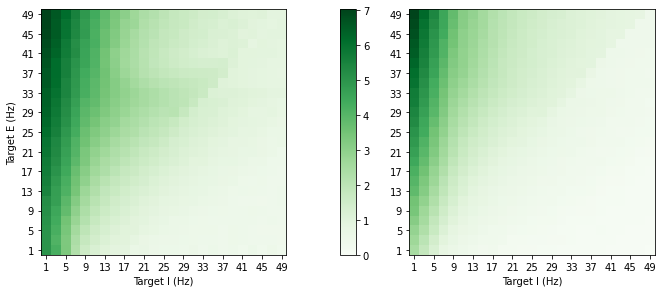

In [14]:
csv_path = "data/fig1/iall_param_sweep_summary.csv"

VALUE_COL_IE = "mean_w_IE_last10s"
VALUE_COL_II = "mean_w_II_last10s"

FIGSIZE = (11, 5)
VMIN, VMAX = 0.0, None
TARGET_I_MAX = 50

df = pd.read_csv(csv_path)

required = ["target_e", "target_i", VALUE_COL_IE, VALUE_COL_II]
df = df.dropna(subset=required)

df = df[df["target_i"] <= TARGET_I_MAX]

target_es = np.sort(df["target_e"].unique())
target_is = np.sort(df["target_i"].unique())

e_index = {v: i for i, v in enumerate(target_es)}
i_index = {v: i for i, v in enumerate(target_is)}

heat_ie = np.full((len(target_es), len(target_is)), np.nan)
heat_ii = np.full((len(target_es), len(target_is)), np.nan)

for _, r in df.iterrows():
    i = e_index[r["target_e"]]
    j = i_index[r["target_i"]]
    heat_ie[i, j] = float(r[VALUE_COL_IE])
    heat_ii[i, j] = float(r[VALUE_COL_II])

fig, (axL, axR) = plt.subplots(1, 2, figsize=FIGSIZE)
fig.subplots_adjust(wspace=0.5)

imL = axL.imshow(
    heat_ie,
    origin="lower",
    cmap="Greens",
    vmin=VMIN,
    vmax=VMAX,
    interpolation="nearest",
    aspect="auto",
)
imR = axR.imshow(
    heat_ii,
    origin="lower",
    cmap="Greens",
    vmin=VMIN,
    vmax=VMAX,
    interpolation="nearest",
    aspect="auto",
)

axL.set_box_aspect(1)
axR.set_box_aspect(1)

step_e = max(1, len(target_es) // 10)
step_i = max(1, len(target_is) // 10)

yticks = range(0, len(target_es), step_e)
xticks = range(0, len(target_is), step_i)

for ax in (axL, axR):
    ax.set_yticks(yticks)
    ax.set_yticklabels([int(x) for x in target_es[::step_e]])
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in target_is[::step_i]])
    ax.set_xlabel("Target I (Hz)")

axL.set_ylabel("Target E (Hz)")
axR.set_ylabel("")

fig.canvas.draw()
posL = axL.get_position()
posR = axR.get_position()
gap = posR.x0 - posL.x1

cbar_width = min(0.02, gap * 0.6)
cax = fig.add_axes([
    posL.x1 + (gap - cbar_width) / 2,
    posL.y0,
    cbar_width,
    posL.height,
])

cbar = fig.colorbar(imL, cax=cax)

plt.show()


## Fig S2: Parameter search over target firing rates of the I-to-E and I-to-I synaptic plasticity, separately.

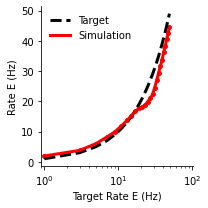

In [15]:
df = pd.read_csv("data/fig1/ie_param_sweep_summary.csv")

x_col = "target_e"
y_actual = "rate_exc_hz"
y_pred = "target_e"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df[y_pred],   color="black", linestyle="--", linewidth=3, label="Target")
ax.plot(df[x_col], df[y_actual], color="red", linestyle="-", linewidth=3, label="Simulation")
ax.scatter(df[x_col], df[y_actual], color="red", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate E (Hz)")
ax.set_ylabel("Rate E (Hz)")
ax.set_xlim(0.9,101)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


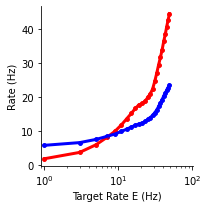

In [16]:
df = pd.read_csv("data/fig1/ie_param_sweep_summary.csv")

x_col = "target_e"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df["rate_exc_hz"],   color="red", linestyle="-", linewidth=3, label="Rate E")
ax.scatter(df[x_col], df["rate_exc_hz"], color="red", s=15)
ax.plot(df[x_col], df["rate_inh_hz"], color="blue", linestyle="-", linewidth=3, label="Rate I")
ax.scatter(df[x_col], df["rate_inh_hz"], color="blue", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate E (Hz)")
ax.set_ylabel("Rate (Hz)")
ax.set_xlim(0.9,101)

plt.tight_layout()
plt.show()

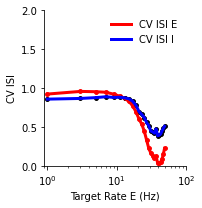

In [17]:
df = pd.read_csv("data/fig1/ie_param_sweep_summary.csv")

x_col = "target_e"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df["cv_isi_exc"],   color="red", linestyle="-", linewidth=3, label="CV ISI E")
ax.scatter(df[x_col], df["cv_isi_exc"], color="red", s=15)
ax.plot(df[x_col], df["cv_isi_inh"],   color="blue", linestyle="-", linewidth=3, label="CV ISI I")
ax.scatter(df[x_col], df["cv_isi_inh"], color="black", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate E (Hz)")
ax.set_ylabel("CV ISI")
ax.set_xlim(0.9,101)
ax.set_ylim(0,2)
ax.legend(frameon=False)

plt.tight_layout()

plt.show()

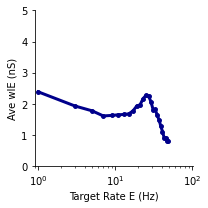

In [18]:
df = pd.read_csv("data/fig1/ie_param_sweep_summary.csv")

x_col = "target_e"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df["mean_w_IE_last10s"],   color="darkblue", linestyle="-", linewidth=3)
ax.scatter(df[x_col], df["mean_w_IE_last10s"], color="darkblue", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate E (Hz)")
ax.set_ylabel("Ave wIE (nS)")
ax.set_xlim(0.9,101)
ax.set_ylim(0,5)
# ax.legend(frameon=False)

plt.tight_layout()

plt.show()

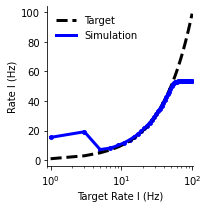

In [19]:
df = pd.read_csv("data/fig1/ii_param_sweep_summary.csv")

x_col = "target_i"
y_actual = "rate_inh_hz"
y_pred = "target_i"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df[y_pred],   color="black", linestyle="--", linewidth=3, label="Target")
ax.plot(df[x_col], df[y_actual], color="blue", linestyle="-", linewidth=3, label="Simulation")
ax.scatter(df[x_col], df[y_actual], color="blue", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate I (Hz)")
ax.set_ylabel("Rate I (Hz)")
ax.set_xlim(0.9,101)
ax.legend(frameon=False)

plt.tight_layout()

plt.show()

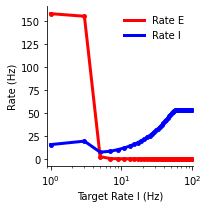

In [20]:
df = pd.read_csv("data/fig1/ii_param_sweep_summary.csv")

x_col = "target_i"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df["rate_exc_hz"],   color="red", linestyle="-", linewidth=3, label="Rate E")
ax.scatter(df[x_col], df["rate_exc_hz"], color="red", s=15)
ax.plot(df[x_col], df["rate_inh_hz"], color="blue", linestyle="-", linewidth=3, label="Rate I")
ax.scatter(df[x_col], df["rate_inh_hz"], color="blue", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate I (Hz)")
ax.set_ylabel("Rate (Hz)")
ax.set_xlim(0.9,101)
ax.legend(frameon=False)

plt.tight_layout()

plt.show()

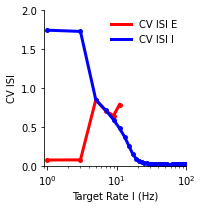

In [21]:
df = pd.read_csv("data/fig1/ii_param_sweep_summary.csv")

x_col = "target_i"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df["cv_isi_exc"],   color="red", linestyle="-", linewidth=3, label="CV ISI E")
ax.scatter(df[x_col], df["cv_isi_exc"], color="red", s=15)
ax.plot(df[x_col], df["cv_isi_inh"],   color="blue", linestyle="-", linewidth=3, label="CV ISI I")
ax.scatter(df[x_col], df["cv_isi_inh"], color="blue", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate I (Hz)")
ax.set_ylabel("CV ISI")
ax.set_xlim(0.9,101)
ax.set_ylim(0,2)
ax.legend(frameon=False)

plt.tight_layout()

plt.show()

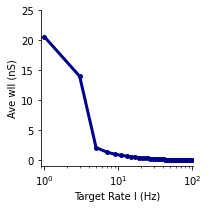

In [22]:
df = pd.read_csv("data/fig1/ii_param_sweep_summary.csv")

x_col = "target_i"

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(df[x_col], df["mean_w_II_last10s"],   color="darkblue", linestyle="-", linewidth=3)
ax.scatter(df[x_col], df["mean_w_II_last10s"], color="darkblue", s=15)

ax.set_xscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Target Rate I (Hz)")
ax.set_ylabel("Ave wII (nS)")
ax.set_xlim(0.9,101)
ax.set_ylim(-1,25)
# ax.legend(frameon=False)

plt.tight_layout()

plt.show()